# Traditional and AI-Generated Scam Text Detection and Risk Scoring System


In [45]:
#!pip install wordcloud

## 1. Load traditional call transcript dataset
We first load the cleaned traditional phone scam call transcripts from `../data/507_traditional_dataset.csv`. This dataset comes from the Kaggle
"Call Transcripts Scam Determinations" resource and contains multiple
fine-grained labels describing different degrees of suspicious or nonsuspicious intent.

In [46]:
import pandas as pd

# Load the traditional call transcript dataset
df = pd.read_csv("../data/507_traditional_dataset.csv")
#specific lable classification
df["LABEL"].unique()

array(['neutral', 'slightly_suspicious', 'suspicious',
       'highly_suspicious', 'legitimate', 'scam',
       'standard_opening, identification_request', 'polite_ending',
       'potential_scam', ' neutral', ' legitimate', ' scam',
       ' scam_response', ' dismissing official protocols"',
       ' emphasizing security and compliance"',
       ' ready for further engagement"',
       ' suggesting a dangerous situation"', 'Scam',
       ' adhering to protocols"', ' citing urgency"', 'scam_response'],
      dtype=object)

## 2. Clean and normalize original labels
The original label field contains many categories, such as “highly_suspicious” and “polite_ending”. To standardize them, we convert all labels to strings, remove extra spaces and quotation marks, and normalize everything to lowercase. The resulting cleaned version is stored in a new field called `LABEL_CLEAN`.

In [47]:
#data cleaning(make sure string, remove the space and residual symbols, unify the lowercase)
df["LABEL_CLEAN"] = (df["LABEL"]
    .astype(str)           
    .str.strip()           
    .str.lower()           
    .str.replace('"', ''))  
df["LABEL_CLEAN"].unique()


array(['neutral', 'slightly_suspicious', 'suspicious',
       'highly_suspicious', 'legitimate', 'scam',
       'standard_opening, identification_request', 'polite_ending',
       'potential_scam', 'scam_response', 'dismissing official protocols',
       'emphasizing security and compliance',
       'ready for further engagement', 'suggesting a dangerous situation',
       'adhering to protocols', 'citing urgency'], dtype=object)

In [48]:
#classify(scam vs non-scam)
scam_keywords = [
    "scam",                # scam, potential_scam, scam_response 
    "suspicious",          # slightly_suspicious / highly_suspicious
    "dangerous",           # suggesting a dangerous situation
    "urgency",             # citing urgency
    "dismissing",          # dismissing official protocols
    "compliance",          # emphasizing security and compliance
    "ready for further engagement"]


## 3. Map labels to three target classes
We combine the detailed labels into three broader classes: `non_scam` for normal or harmless conversation, `traditional_scam` for human-written fraudulent or suspicious content, and `ai_scam` for AI-generated scam messages that will be added later. Based on these definitions, we create a simple rule-based mapping that converts each `LABEL_CLEAN` value into a numeric `label_id` and a human-readable `label_text`.

In [49]:
#mapping fuction
def map_label_to_class(label_clean: str):
    for kw in scam_keywords:
        if kw in label_clean:
            return 1, "traditional_scam"
    return 0, "non_scam"
df[["label_id", "label_text"]] = df["LABEL_CLEAN"].apply(
    lambda x: pd.Series(map_label_to_class(x))
)
df["label_text"].value_counts()

label_text
traditional_scam    397
non_scam            253
Name: count, dtype: int64

After applying this mapping, we construct a standardized training DataFrame and save it for use in later steps.

In [50]:
#build a standardized training DataFrame
df_std = pd.DataFrame({
    "id": range(len(df)),
    "text": df["TEXT"],             
    "label_id": df["label_id"],
    "label_text": df["label_text"],
    "source": "Kaggle_Call Transcripts Scam Determinations",  
    "is_synthetic": 0})

#new file
output_path = "../data/traditional_calls_standardized.csv"
df_std.to_csv(output_path, index=False)
output_path

'../data/traditional_calls_standardized.csv'

## 4. Load Qwen2.5-1.5B-Instruct model from Hugging Face
Here we load the Qwen2.5-1.5B-Instruct model and its tokenizer using the Hugging Face `transformers` library. The model is moved to CPU for inference in this notebook environment.

In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True)
model.to("cpu")

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

## 5. AI-Generated Scam Data Construction
This function takes a short scenario description and prompts the Qwen2.5-1.5B-Instruct model to generate a realistic phone-style scam message.
### 5.1 Define message generation function

In [39]:
def generate_ai_scam_text(scenario: str) -> str:
    """
    Use Qwen2.5-1.5B-Instruct to generate one AI-style scam message.
    Output only the scam message itself.
    """
    prompt = (
    f"Scenario: {scenario}\n"
    "Generate a short scam message spoken by a phone caller.\n"
    "Make it sound like real spoken language: slightly rushed, informal, and a bit hesitant.\n"
    "Avoid email style, avoid paragraphs, avoid HTML, avoid <br>.\n"
    "Do NOT ask for money directly. Instead, talk around the issue and hint at urgency.\n"
    "Optionally include 1–3 natural fillers such as 'uh', 'listen', or 'I mean', but do not overuse them.\n"
    "Do not repeat the same word or filler more than twice in a row.\n"
    "Keep the message fluent and easy to understand, without stuttering.\n"
    "Keep it short: 20–45 words.\n"
    "Use placeholders like <NAME>, <BANK>, <ACCOUNT>.\n"
    "Output ONLY the spoken message.\n"
    "\nMessage:\n"
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    outputs = model.generate(
        **inputs,
        max_new_tokens=60,
        do_sample=True,
        temperature=0.8,
        top_p=0.9,)
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    if "Message:" in full_text:
        return full_text.split("Message:")[-1].strip()
    else:
        return full_text.strip()


In [40]:
# Quick test: generate one AI-style scam message for a sample banking scenario.
# This helps verify that the model is responding to the scenario prompt correctly.

print(generate_ai_scam_text(
    "AI-written bank notification saying that the user's account is temporarily locked and asking them to verify their identity via a fake online link."
))

<PHONE_NUMBER> Hello there! I hope this calls you well. Just wanted to remind you about your <BANK> account... uh... something happened with it. Could you please verify your identity now? It's important, so let me know right away. Thanks!

Hello there! I hope


### 5.2 Define AI scam generation scenarios
We prepare a list of realistic scam scenarios that will be used as input to the `generate_ai_scam_text` function. Each scenario provides a short description of a typical fraudulent situation. The model will generate multiple messages per scenario in the next step.

In [41]:
#setting scenarios
ai_scam_scenarios = [
    # 1. AI-generated voice spoofing a family member
    "AI voice deepfake pretending to be a family member who claims to be in urgent trouble and needs money immediately.",
    # 2. AI-written bank fraud notification
    "AI-written bank notification saying that the user's account is temporarily locked and asking them to verify their identity via a fake online link.",
    # 3. AI-generated message impersonating delivery or logistics support
    "AI-generated message impersonating a delivery or shipping company, asking the user to pay an extra customs or service fee through a fake payment page.",
    # 4. AI-generated email pretending to be a school or immigration office
    "AI-generated email pretending to be from a university or immigration office, asking the user to upload sensitive personal documents to a fraudulent website.",
    # 5. AI-generated investment scam
    "AI-generated investment scam promising unusually high returns with low risk, asking the user to transfer money to a so-called secure investment account."
]

### 5.3 Generate AI scam messages for all scenarios
For each scam scenario defined earlier, we generate multiple AI-style scam messages using the `generate_ai_scam_text` function. `tqdm` progress bars are used to show generation progress. The results are stored in a list of dictionaries and converted into a DataFrame.

In [42]:
from tqdm import tqdm
import pandas as pd
rows = []
num_per_scenario = 10
for scenario in tqdm(ai_scam_scenarios, desc="Generating by Scenario"):
    for i in tqdm(range(num_per_scenario), desc=f"{scenario[:25]}..", leave=False):
        text = generate_ai_scam_text(scenario)
        rows.append({
            "text": text,
            "label_id": 2,
            "label_text": "ai_scam",
            "source": "qwen_generated",
            "scenario": scenario,
            "is_synthetic": 1})
df_ai = pd.DataFrame(rows)
df_ai.head(), df_ai["label_text"].value_counts()

Generating by Scenario: 100%|█████████████████████| 5/5 [06:55<00:00, 83.14s/it]


(                                                text  label_id label_text  \
 0  Listen, I'm in uh... <PHONE_NUMBER>. This is m...         2    ai_scam   
 1  Uhhh... listen, my mom's uh... her computer br...         2    ai_scam   
 2  "Listen, listen, this is my brother! He's in u...         2    ai_scam   
 3  "Listen, uh, I'm sorry, my dad's been uh, he g...         2    ai_scam   
 4  Uh... listen... uh, my grandpa... he's in a bi...         2    ai_scam   
 
            source                                           scenario  \
 0  qwen_generated  AI voice deepfake pretending to be a family me...   
 1  qwen_generated  AI voice deepfake pretending to be a family me...   
 2  qwen_generated  AI voice deepfake pretending to be a family me...   
 3  qwen_generated  AI voice deepfake pretending to be a family me...   
 4  qwen_generated  AI voice deepfake pretending to be a family me...   
 
    is_synthetic  
 0             1  
 1             1  
 2             1  
 3            

In [43]:
#Save the generated AI scam dataset
ai_path = "../data/ai_scam_qwen_generated.csv"
df_ai.to_csv(ai_path, index=False)
ai_path

'../data/ai_scam_qwen_generated.csv'

## 6. Merge traditional scam data and AI-generated scam data
We load the standardized traditional dataset, align the schema of the AI-generated dataset, and concatenate both into a single combined dataset. The final dataset contains:`non_scam `,`traditional_scam` and `ai_scam`.

In [44]:
df_trad = pd.read_csv("../data/traditional_calls_standardized.csv")
df_trad.head()
# add id for AI data
df_ai_std = df_ai.reset_index().rename(columns={"index": "id"})
df_ai_std = df_ai_std[["id", "text", "label_id", "label_text", "source", "is_synthetic"]]
#
df_trad_std = df_trad[["id", "text", "label_id", "label_text", "source", "is_synthetic"]]

# combine:non_scam + traditional_scam）+AI scam
df_all = pd.concat([df_trad_std, df_ai_std], ignore_index=True)

df_all["label_text"].value_counts(), df_all.head()

(label_text
 traditional_scam    397
 non_scam            253
 ai_scam              50
 Name: count, dtype: int64,
    id                                               text  label_id label_text  \
 0   0  Good morning, this is [Your Name]'s personal a...         0   non_scam   
 1   1  Hello, my name is Jamie. I'm interested in vol...         0   non_scam   
 2   2  Yes, I'm really passionate about environmental...         0   non_scam   
 3   3  Great, how do I sign up, and where can I find ...         0   non_scam   
 4   4  Could you send me the link, please? And my ema...         0   non_scam   
 
                                         source  is_synthetic  
 0  Kaggle_Call Transcripts Scam Determinations             0  
 1  Kaggle_Call Transcripts Scam Determinations             0  
 2  Kaggle_Call Transcripts Scam Determinations             0  
 3  Kaggle_Call Transcripts Scam Determinations             0  
 4  Kaggle_Call Transcripts Scam Determinations             0  )

In [51]:
# Save the merged full dataset (traditional + AI-generated)
full_path = "../data/call_scam_dataset_traditional_and_ai_qwen.csv"
df_all.to_csv(full_path, index=False)
full_path

'../data/call_scam_dataset_traditional_and_ai_qwen.csv'

In [52]:
#read data
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv("../data/call_scam_dataset_traditional_and_ai_qwen.csv")
print("Dataset loaded. Shape:", df.shape)
print("\nLabel distribution:\n", df["label_id"].value_counts())

Dataset loaded. Shape: (700, 6)

Label distribution:
 label_id
1    397
0    253
2     50
Name: count, dtype: int64


## 7. Split dataset into Train / Validation / Test sets
We split the full dataset into:70% training data, 15% validation data, 15% test data. Stratified splitting is used to preserve the label distribution, especially because the AI-scam class (label 2) has fewer samples.

In [54]:
#split Train / Val / Test data
X = df["text"]
y = df["label_id"]
# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y, # AI scam only has 50(small), ensure data is distributed proportionally across the train,val,and test
    random_state=42
)
# 30% → 15% val + 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)
print("\nSplit sizes:")
print("Train:", len(X_train))
print("Val:", len(X_val))
print("Test:", len(X_test))

print("\nTrain labels:\n", y_train.value_counts())
print("\nVal labels:\n", y_val.value_counts())
print("\nTest labels:\n", y_test.value_counts())


Split sizes:
Train: 490
Val: 105
Test: 105

Train labels:
 label_id
1    278
0    177
2     35
Name: count, dtype: int64

Val labels:
 label_id
1    59
0    38
2     8
Name: count, dtype: int64

Test labels:
 label_id
1    60
0    38
2     7
Name: count, dtype: int64


## 8. TF–IDF vectorization
We convert raw text into numerical features using a TF–IDF vectorizer. The vectorizer is fitted on the training set and then applied to the validation and test sets.  

In [55]:
#TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
# Create a TF-IDF vector generator
tfidf = TfidfVectorizer(
    lowercase=True,       
    ngram_range=(1, 2),    # unigram + bigram capture short phrases
    max_features=5000,     # contain a maximum of 5000 words to prevent it from becoming too large.
    min_df=2               # Only samples that have appeared in at least two samples are retained.
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Val TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (490, 2646)
Val TF-IDF shape: (105, 2646)
Test TF-IDF shape: (105, 2646)


## 9. Train Logistic Regression baseline model
We train a multinomial Logistic Regression classifier on the TF–IDF features. `class_weight='balanced'` is used to reduce the effect of class imbalance, since the AI-scam class is much smaller than the others.

In [56]:
#logistic regression
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(
    max_iter=300,
    class_weight='balanced',
    n_jobs=-1
)
clf.fit(X_train_tfidf, y_train)
print("Model training complete.")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Model training complete.


## 10. Visualization and Model Interpretation 
This section presents confusion matrices, classification reports, TF–IDF feature analyses, and word cloud visualizations to interpret how the model distinguishes between the three scam classes.

### 10.1 Classification report and confusion matrix
We evaluate the Logistic Regression classifier using: predicted labels on the test set; precision, recall, and F1-scores (classification report) and confusion matrix visualization This helps us understand which classes the model predicts accurately and where misclassifications occur.

Classification Report:
              precision    recall  f1-score   support

           0     0.9714    0.8947    0.9315        38
           1     0.9219    0.9833    0.9516        60
           2     1.0000    0.8571    0.9231         7

    accuracy                         0.9429       105
   macro avg     0.9644    0.9117    0.9354       105
weighted avg     0.9450    0.9429    0.9424       105



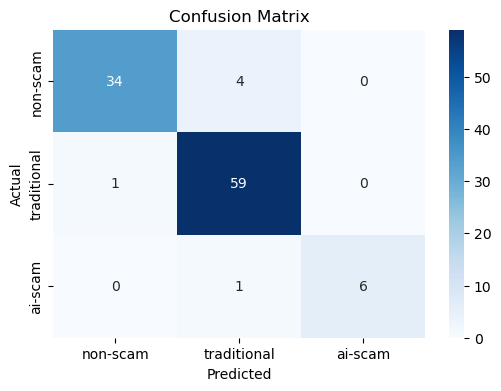

In [65]:
#evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
# 1. predict
y_pred = clf.predict(X_test_tfidf)
# 2. report
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))
# 3. confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d",
            xticklabels=["non-scam", "traditional", "ai-scam"],
            yticklabels=["non-scam", "traditional", "ai-scam"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 10.2 Top TF–IDF feature terms
To better understand what the Logistic Regression model has learned, we extract the top 15 highest-weighted TF–IDF features for each class. These terms help explain why certain messages are classified as non-scam,traditional scam, or AI-generated scam.

In [59]:
#Extract the top 15 feature words for each category
import numpy as np
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_
def top_terms_for_class(class_index, top_n=15):
    # Take the weight corresponding to this class
    coef = coefs[class_index]
    # The features of the top_n rank
    top_ids = np.argsort(coef)[-top_n:]
    return feature_names[top_ids][::-1]  # Arranged from largest to smallest

print("Top terms — non-scam (0):")
print(top_terms_for_class(0))

print("\nTop terms — traditional scam (1):")
print(top_terms_for_class(1))

print("\nTop terms — AI scam (2):")
print(top_terms_for_class(2))

Top terms — non-scam (0):
['step' 'your name' 'name' 'thank you' 'you' 'assistant' 'event' 'thank'
 'may' 'assist' 'the' 'be' 'email' 'how' 'for']

Top terms — traditional scam (1):
['security' 'we' 'official' 'you provide' 'proceed' 'provide' 'immediate'
 'not' 'over' 'goodbye' 'time' 'over the' 'grandson' 'verification'
 'details about']

Top terms — AI scam (2):
['uh' 'listen' 'okay' 'some' 'they' 'just' 'my' 'right' 'need' 'hey'
 'fees' 'uh uh' 'you know' 'there' 'got']


### 10.3 Wordcloud 
To visually inspect the most influential words learned by the classifier,
we generate word clouds for each class. The word size represents the weight of each feature in the Logistic Regression model.

In [60]:
#wordcloud
import numpy as np

feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_

def get_top_terms_with_weights(class_index, top_n=50):
    """
    Returns the top_n features of a given category and their weights.
    """
    coef = coefs[class_index]
    top_idx = np.argsort(coef)[-top_n:]
    top_features = feature_names[top_idx]
    top_weights = coef[top_idx]
    
    order = np.argsort(top_weights)[::-1]
    return top_features[order], top_weights[order]

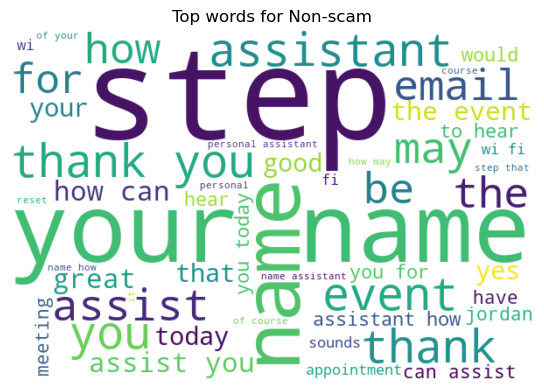

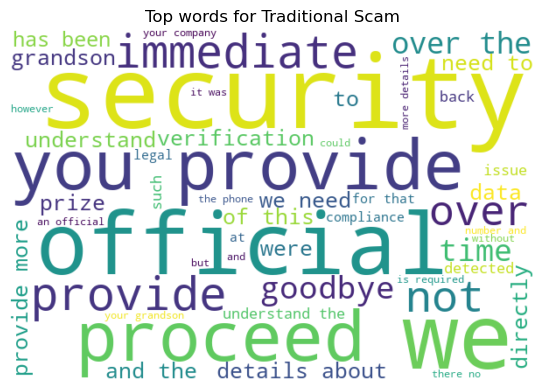

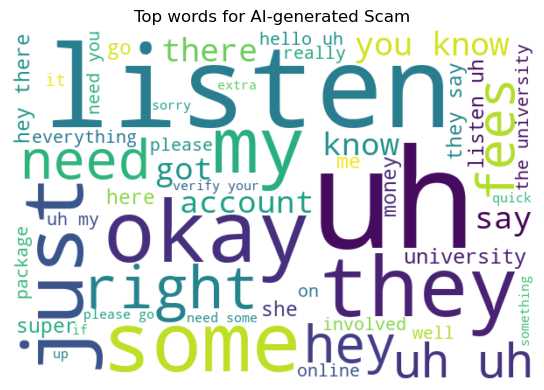

In [61]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_wordcloud_for_class(class_index, class_name, top_n=50):
    terms, weights = get_top_terms_with_weights(class_index, top_n=top_n)
    freq_dict = {term: float(w) for term, w in zip(terms, weights)}
    
    wc = WordCloud(
        width=600,
        height=400,
        background_color="white"   
    ).generate_from_frequencies(freq_dict)
    
    plt.figure(figsize=(6, 4))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Top words for {class_name}")
    plt.tight_layout()
    plt.show()
plot_wordcloud_for_class(0, "Non-scam")
plot_wordcloud_for_class(1, "Traditional Scam")
plot_wordcloud_for_class(2, "AI-generated Scam")

## 11. Scam risk scoring system
We define a helper function `score_message` that takes a raw text message and outputs a scalar risk score, a discrete risk level, and class probabilities for non-scam, traditional scam, and AI-generated scam. The risk score is calculated as the combined probability of the two scam classes, giving a simple measure of how likely the message is to contain fraudulent content.

In [66]:
#Scam Risk Scoring System
def score_message(text: str):
    """
    Calculate fraud risk score and level for each individual text message.
    """
    # Text -> TF-IDF
    X_vec = tfidf.transform([text])
    
    # prediction probability
    proba = clf.predict_proba(X_vec)[0]  
    p_non, p_trad, p_ai = proba
    
    # Risk score = Probability of traditional fraud + AI fraud
    risk_score = p_trad + p_ai
    
    # level
    if risk_score < 0.3:
        level = "low"
    elif risk_score < 0.7:
        level = "medium"
    else:
        level = "high"
    
    return {
        "risk_score": float(risk_score),
        "risk_level": level,
        "p_non_scam": float(p_non),
        "p_traditional_scam": float(p_trad),
        "p_ai_scam": float(p_ai)
    }

In [67]:
#test
example = "Uh, listen, something weird happened with my account, can you help real quick?"
score_message(example)

{'risk_score': 0.8795035065019245,
 'risk_level': 'high',
 'p_non_scam': 0.12049649349807544,
 'p_traditional_scam': 0.11767993681305704,
 'p_ai_scam': 0.7618235696888676}

### 11.1 Visualization of Scam Risk Scores
This section visualizes the scam risk scores generated by the model.

KDE curves shows how the overall risk scores distribute across the three true classes

/var/folders/ln/khxt8skj3gd11csrrsts0nhw0000gn/T/ipykernel_2995/3260310302.py:12: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(risk_scores[labels==0], label="Non-scam", shade=True)
/var/folders/ln/khxt8skj3gd11csrrsts0nhw0000gn/T/ipykernel_2995/3260310302.py:13: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(risk_scores[labels==1], label="Traditional Scam", shade=True)
/var/folders/ln/khxt8skj3gd11csrrsts0nhw0000gn/T/ipykernel_2995/3260310302.py:14: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(risk_scores[labels==2], label="AI Scam", shade=True)


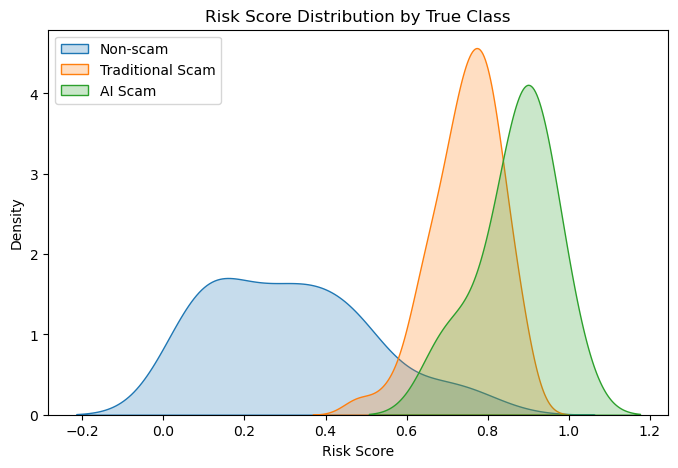

In [68]:
#visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Get the risk score for each class in the test set
proba_test = clf.predict_proba(X_test_tfidf)
risk_scores = proba_test[:,1] + proba_test[:,2]  # scam risk

labels = y_test.values  

plt.figure(figsize=(8,5))
sns.kdeplot(risk_scores[labels==0], label="Non-scam", shade=True)
sns.kdeplot(risk_scores[labels==1], label="Traditional Scam", shade=True)
sns.kdeplot(risk_scores[labels==2], label="AI Scam", shade=True)
plt.title("Risk Score Distribution by True Class")
plt.xlabel("Risk Score")
plt.ylabel("Density")
plt.legend()
plt.show()

Boxplots method shows score statistics, providing a structured comparison of class risk levels.

/var/folders/ln/khxt8skj3gd11csrrsts0nhw0000gn/T/ipykernel_2995/3256413296.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="true_label", y="risk_score", data=df_scores,


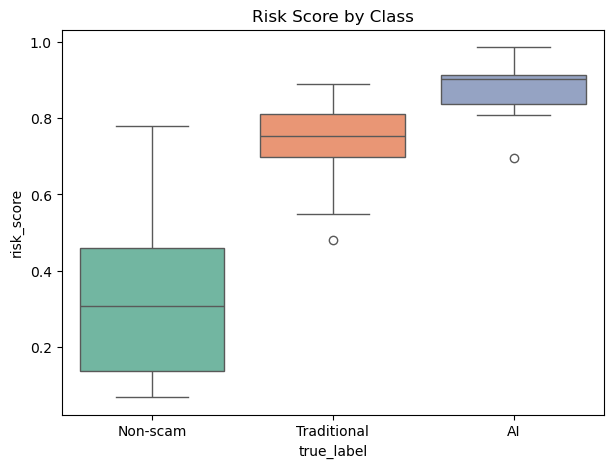

In [69]:
#Create a boxplot to display boundaries, outliers, and overlaps.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_scores = pd.DataFrame({
    "risk_score": risk_scores,
    "true_label": labels
})

plt.figure(figsize=(7,5))
sns.boxplot(x="true_label", y="risk_score", data=df_scores,
            palette="Set2")
plt.xticks([0,1,2], ["Non-scam","Traditional","AI"])
plt.title("Risk Score by Class")
plt.show()

## 12. Additional Baseline Models
This section trains Multinomial Naive Bayes and a linear SVM using the same TF-IDF features for comparison.

In [71]:
#comparison Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

y_pred_nb = nb.predict(X_test_tfidf)

print("=== Naive Bayes Performance ===")
print(classification_report(y_test, y_pred_nb, digits=4))

=== Naive Bayes Performance ===
              precision    recall  f1-score   support

           0     1.0000    0.8421    0.9143        38
           1     0.8333    1.0000    0.9091        60
           2     1.0000    0.1429    0.2500         7

    accuracy                         0.8857       105
   macro avg     0.9444    0.6617    0.6911       105
weighted avg     0.9048    0.8857    0.8670       105



In [64]:
##comparison Linear SVM
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

y_pred_svm = svm.predict(X_test_tfidf)

print("=== Linear SVM Performance ===")
print(classification_report(y_test, y_pred_svm, digits=4))

=== Linear SVM Performance ===
              precision    recall  f1-score   support

           0     0.9444    0.8947    0.9189        38
           1     0.9062    0.9667    0.9355        60
           2     1.0000    0.7143    0.8333         7

    accuracy                         0.9238       105
   macro avg     0.9502    0.8586    0.8959       105
weighted avg     0.9263    0.9238    0.9227       105

